In [1]:
# Import statements
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Special imports
import mlqmcpy as mp
from mlqmcpy.problems.elliptic import solve_elliptic_pde, elliptic

In [3]:
# OPTIONS
num_levels = 3
cost_per_level = [
    2 ** (level - num_levels + 1) for level in range(num_levels)
]  # Rescale so that finest level has unit cost
initial_sample_size = 4
error_tolerance = 1e-3
iterator = mp.GreedyMLQMCIterator(
    8,
    initial_sample_size=initial_sample_size,
    cost_per_level=cost_per_level,
    error_tolerance=error_tolerance,
    replications=10,
)

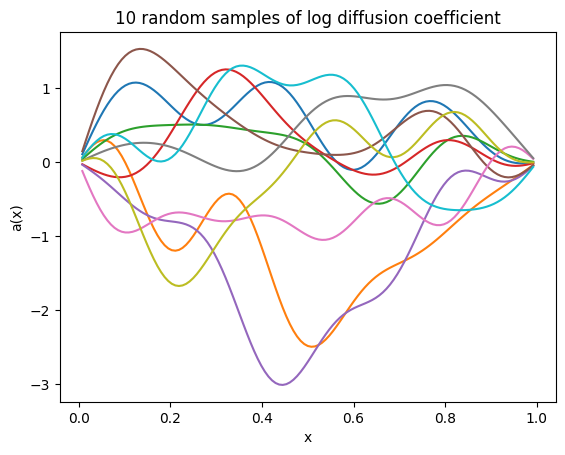

In [4]:
# Plot coefficients
_, ax = plt.subplots()
for _ in range(10):
    _, x, a_x, _ = solve_elliptic_pde(return_data=True)
    ax.plot(x, np.log(a_x))
ax.set_xlabel("x")
ax.set_ylabel("a(x)")
ax.set_title("10 random samples of log diffusion coefficient")
plt.show()

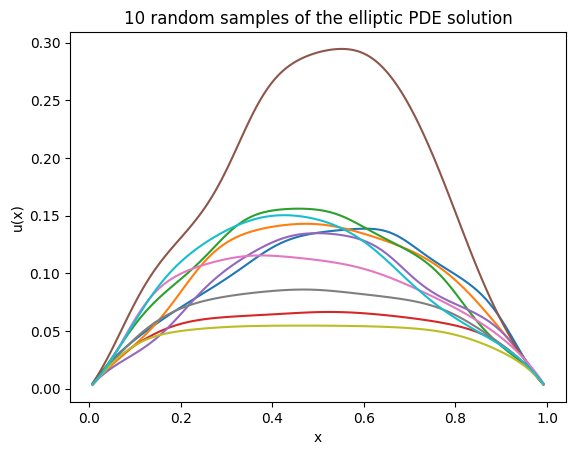

In [5]:
# Plot solutions
_, ax = plt.subplots()
for _ in range(10):
    _, x, _, u = solve_elliptic_pde(return_data=True)
    ax.plot(x, u)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("10 random samples of the elliptic PDE solution")
plt.show()

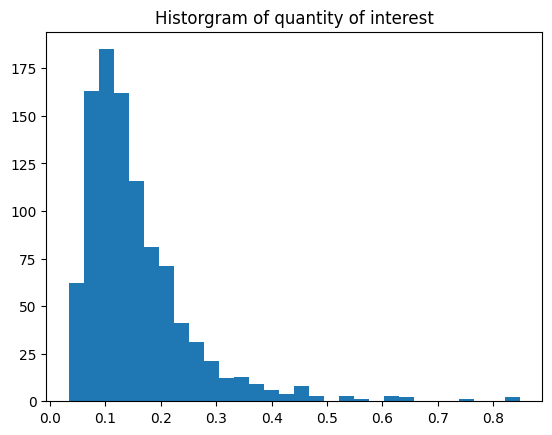

In [6]:
# Plot histogram
_, ax = plt.subplots()
u_samples = [solve_elliptic_pde(4) for _ in range(1000)]
ax.hist(u_samples, bins=30)
ax.set_title("Historgram of quantity of interest")
plt.show()

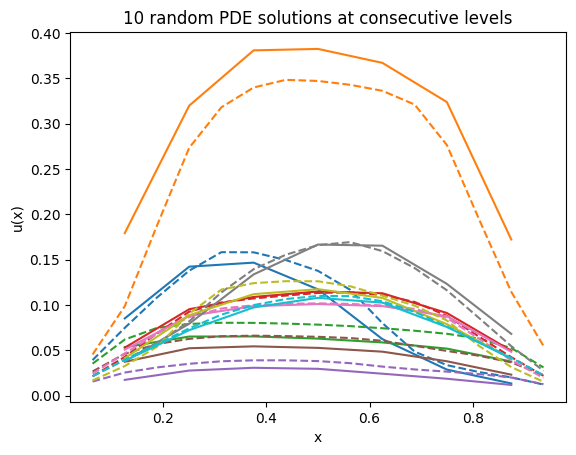

In [7]:
# Check correlations
_, ax = plt.subplots()
for j in range(10):
    coeffs = np.random.rand(8)
    _, x, _, u = solve_elliptic_pde(1, coeffs, return_data=True)
    ax.plot(x, u, color=f"C{j}")
    _, x, _, u = solve_elliptic_pde(2, coeffs, return_data=True)
    ax.plot(x, u, color=f"C{j}", linestyle="dashed")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("10 random PDE solutions at consecutive levels")
plt.show()

In [8]:
# Iterate over the sampler
for iter, new_samples in enumerate(iterator):

    print(f"\nIteration {iter}\n")

    # Solve the PDE
    new_results = {
        level: [elliptic.ml(level, sample) for sample in samples]
        for level, samples in new_samples.items()
    }

    # Update the sampler with computed outputs
    iterator.update(new_results)

    # Print status
    iterator.print_status()
    print(
        f"Current error: {iterator.standard_error:.3e}, current cost: {int(iterator.cost)}"
    )


Iteration 0

+-------------------+---------------+--------------+----------------+
| number of samples |      mean     |   variance   | standard error |
+-------------------+---------------+--------------+----------------+
|            10 x 4 |  0.1478185378 | 0.0130503248 |  0.0084637910  |
|            10 x 4 | -0.0150081137 | 0.0038753401 |  0.0057446136  |
|            10 x 4 |  0.0024561395 | 0.0001056402 |  0.0010949472  |
+-------------------+---------------+--------------+----------------+
Current error: 1.029e-02, current cost: 70

Iteration 1

+-------------------+---------------+--------------+----------------+
| number of samples |      mean     |   variance   | standard error |
+-------------------+---------------+--------------+----------------+
|            10 x 8 |  0.1469375307 | 0.0133339708 |  0.0054054431  |
|            10 x 4 | -0.0150081137 | 0.0038753401 |  0.0057446136  |
|            10 x 4 |  0.0024561395 | 0.0001056402 |  0.0010949472  |
+------------------